In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [184]:
df = pd.read_csv("")

# Cleaned Data.

In [185]:
df

,Brand,UniqueID,Range (Km),Efficiency (Wh/km),Acceleration (0-100),Battery (kWh),FastCharge (kW),Cargo (L),Price_per_Range (/km),Germany_Price(€),Segment
0,BMW,3290,610,178,4.9,108.7,230.0,578.0,114.0,70900.0,D - Large
1,MG,1708,360,171,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium
2,Tesla,3403,445,135,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large
3,BMW,1472,360,197,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive
4,Mercedes,3139,585,145,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large
...,...,...,...,...,...,...,...,...,...,...,...
12325,Porsche,1931,425,197,3.3,83.7,200.0,489.0,380.0,165848.0,F - Luxury
12326,Opel,1345,185,250,12.1,46.3,74.0,NaN,306.0,56700.0,N - Passenger Van
12327,Ford,3164,235,272,9.0,64.0,105.0,819.0,295.0,67771.0,N - Passenger Van
12328,Citroen,1340,185,250,12.1,46.3,74.0,140.0,275.0,50880.0,N - Passenger Van


In [186]:
df = df.rename(columns={
    'Brand': 'brand',
    'UniqueID': 'unique_id',
    'Range (Km)': 'range_km',
    'Efficiency (Wh/km)': 'efficiency_wh_km',
    'Acceleration (0-100)': 'acceleration',
    'Battery (kWh)': 'battery_kwh',
    'FastCharge (kW)': 'fast_charge_kw',
    'Cargo (L)': 'cargo_capacity(l)',
    'Price_per_Range (/km)': 'price_per_range_km_eur',
    'Germany_Price(€)': 'germany_price_eur',
    'Segment': 'segment'
})
df.head()

,brand,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur,segment
0,BMW,3290,610,178,4.9,108.7,230.0,578.0,114.0,70900.0,D - Large
1,MG,1708,360,171,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium
2,Tesla,3403,445,135,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large
3,BMW,1472,360,197,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive
4,Mercedes,3139,585,145,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large


In [187]:
len(df.columns)

11

# Describing about the data
- Dataset contains EV Car and its specifications such as range, battery capacity, charging speed, efficiency, price and vehicle segment across multiple brands.

# Column Understanding & Data Dictionary

- Analyzed which features 'importance' and thier 'meaning' and 'Type' before going to Data

| Column     | Meaning                   | Type        |
| ---------- | ------------------------- | ----------- |
| Brand      | Manufacturer name         | Categorical |
| Segment    | Vehicle market segment    | Categorical |
| Range      | Real-world driving range  | Numerical   |
| Battery    | Battery capacity          | Numerical   |
| Efficiency | Energy consumption per km | Numerical   |
| FastCharge | Fast charging power       | Numerical   |
| Price      | Vehicle price             | Numerical   |


# Columns Description

**brand**  
Manufacturer or automotive company that produces the EV model (e.g., Tesla, BMW, Hyundai).

---

**unique_id**  
Unique identifier extracted from the vehicle URL used to distinguish each EV model in the dataset.

---

**range_km**  
Real-world driving distance the EV can travel on a full battery charge, measured in kilometers.

---

**efficiency_wh_km**  
Energy consumed by the vehicle to travel one kilometer, measured in watt-hours per km (Wh/km). Lower values indicate better energy efficiency.

---

**acceleration_0_100**  
Time required for the vehicle to accelerate from 0 to 100 km/h, measured in seconds. Lower values indicate better performance.

---

**battery_kwh**  
Total usable battery capacity of the EV measured in kilowatt-hours (kWh), representing the amount of stored electrical energy.

---

**fast_charge_kw**  
Maximum DC fast-charging power supported by the vehicle, measured in kilowatts (kW), indicating how quickly the battery can recharge.

---


**cargo_capacity_l**  
Available storage space in the vehicle’s cargo area or trunk, measured in liters.

---

**germany_price_eur**  
Estimated retail price of the EV in Germany, expressed in euros (€).

---

**segment**  
Vehicle classification based on size and market category (e.g., Compact, Medium, SUV, Luxury).

# Data Validation

In [188]:
df.describe()

,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12060.000000,12330.000000,11420.000000
mean,2206.420925,376.309813,190.570965,7.187835,71.005028,113.382806,501.593698,175.579886,65254.471103
std,792.683363,112.489975,29.956224,3.000508,21.242028,56.338255,192.712153,75.682540,35585.578535
min,1004.000000,85.000000,109.000000,2.000000,14.500000,0.000000,1.000000,78.000000,16900.000000
25%,1589.000000,300.000000,169.000000,4.900000,58.000000,76.000000,385.000000,122.000000,43435.000000
50%,2026.000000,385.000000,183.000000,6.700000,74.000000,103.000000,500.000000,148.000000,55375.000000
75%,3130.000000,455.000000,204.000000,8.700000,86.000000,136.000000,588.000000,213.000000,74149.000000
max,3483.000000,720.000000,295.000000,22.400000,123.000000,330.000000,990.000000,828.000000,379015.000000


In [189]:
df.min()

brand                       Abarth
unique_id                     1004
range_km                        85
efficiency_wh_km               109
acceleration                   2.0
battery_kwh                   14.5
fast_charge_kw                 0.0
cargo_capacity(l)              1.0
price_per_range_km_eur        78.0
germany_price_eur          16900.0
segment                   A - Mini
dtype: object

In [190]:
df.max()

brand                        firefly
unique_id                       3483
range_km                         720
efficiency_wh_km                 295
acceleration                    22.4
battery_kwh                    123.0
fast_charge_kw                 330.0
cargo_capacity(l)              990.0
price_per_range_km_eur         828.0
germany_price_eur           379015.0
segment                   S - Sports
dtype: object

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand                   12330 non-null  object 
 1   unique_id               12330 non-null  int64  
 2   range_km                12330 non-null  int64  
 3   efficiency_wh_km        12330 non-null  int64  
 4   acceleration            12330 non-null  float64
 5   battery_kwh             12330 non-null  float64
 6   fast_charge_kw          12330 non-null  float64
 7   cargo_capacity(l)       12060 non-null  float64
 8   price_per_range_km_eur  12330 non-null  float64
 9   germany_price_eur       11420 non-null  float64
 10  segment                 12330 non-null  object 
dtypes: float64(6), int64(3), object(2)
memory usage: 1.0+ MB


- **Summary** : Realized that `price_per_range_km` data type is in Object apart from that Every column data is realistic and analyzable.

In [192]:
df.head()

,brand,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur,segment
0,BMW,3290,610,178,4.9,108.7,230.0,578.0,114.0,70900.0,D - Large
1,MG,1708,360,171,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium
2,Tesla,3403,445,135,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large
3,BMW,1472,360,197,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive
4,Mercedes,3139,585,145,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large


#### Data is validated.

# Missing Value Handling and Analysis

In [193]:
# checking whether Missing values is there or not?

df.isnull().sum()

brand                       0
unique_id                   0
range_km                    0
efficiency_wh_km            0
acceleration                0
battery_kwh                 0
fast_charge_kw              0
cargo_capacity(l)         270
price_per_range_km_eur      0
germany_price_eur         910
segment                     0
dtype: int64

In [194]:
missing_percent = df.isnull().mean()*100
missing_percent.sort_values(ascending=False)

germany_price_eur         7.380373
cargo_capacity(l)         2.189781
brand                     0.000000
unique_id                 0.000000
range_km                  0.000000
efficiency_wh_km          0.000000
acceleration              0.000000
battery_kwh               0.000000
fast_charge_kw            0.000000
price_per_range_km_eur    0.000000
segment                   0.000000
dtype: float64

# Handling Missing Values

- Observation and Interpretation :
    - **Towing_kg** :Many EVs do not support towing, so missing values may represent no towing capability.
    - **Cargo** : Cargo space varies by vehicle type, so better to use median.
    - **Germany_Price_INR,Price_per_km** : filled with median 

In [195]:
bins = [0,250,400,550,1000]

labels = ["short","mid","long","premium"]

df["range_group"] = pd.cut(df["range_km"], bins=bins, labels=labels)

In [196]:
df.head()

,brand,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur,segment,range_group
0,BMW,3290,610,178,4.9,108.7,230.0,578.0,114.0,70900.0,D - Large,premium
1,MG,1708,360,171,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium,mid
2,Tesla,3403,445,135,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large,long
3,BMW,1472,360,197,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive,mid
4,Mercedes,3139,585,145,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large,premium


In [197]:
# df["price_per_km_eur"] = (
#     df.groupby("range_group")["price_per_km_eur"]
#     .transform(lambda x: x.fillna(x.median()))
# )

In [200]:
df["cargo_capacity_l"] = (
    df.groupby("segment")["cargo_capacity(l)"]
    .transform(lambda x: x.fillna(x.median()))
)



In [201]:
df["germany_price_eur"] = (
    df.groupby("segment")["germany_price_eur"]
    .transform(lambda x: x.fillna(x.median()))
)

In [202]:
df.head()

,brand,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur,segment,range_group,cargo_capacity_l
0,BMW,3290,610,178,4.9,108.7,230.0,578.0,114.0,70900.0,D - Large,premium,578.0
1,MG,1708,360,171,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium,mid,363.0
2,Tesla,3403,445,135,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large,long,682.0
3,BMW,1472,360,197,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive,mid,500.0
4,Mercedes,3139,585,145,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large,premium,506.0


In [203]:
df.isnull().sum()

brand                       0
unique_id                   0
range_km                    0
efficiency_wh_km            0
acceleration                0
battery_kwh                 0
fast_charge_kw              0
cargo_capacity(l)         270
price_per_range_km_eur      0
germany_price_eur           0
segment                     0
range_group                 0
cargo_capacity_l            0
dtype: int64

### Handled Missing Values

# Outlier Detection

In [204]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['unique_id', 'range_km', 'efficiency_wh_km', 'acceleration',
       'battery_kwh', 'fast_charge_kw', 'cargo_capacity(l)',
       'price_per_range_km_eur', 'germany_price_eur', 'cargo_capacity_l'],
      dtype='object')

In [205]:
def detect_outliers(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    return {
        "column": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outliers.shape[0]
    }

In [206]:
outlier_summary = []

for i in num_cols:
    result = detect_outliers(df, i)
    outlier_summary.append(result)

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,column,lower_bound,upper_bound,outlier_count
0,unique_id,-722.5,5441.5,0
1,range_km,67.5,687.5,10
2,efficiency_wh_km,116.5,256.5,810
3,acceleration,-0.8,14.4,160
4,battery_kwh,16.0,128.0,60
5,fast_charge_kw,-14.0,226.0,590
6,cargo_capacity(l),80.5,892.5,1170
7,price_per_range_km_eur,-14.5,349.5,330
8,germany_price_eur,-175.0,116265.0,880
9,cargo_capacity_l,88.0,888.0,1170


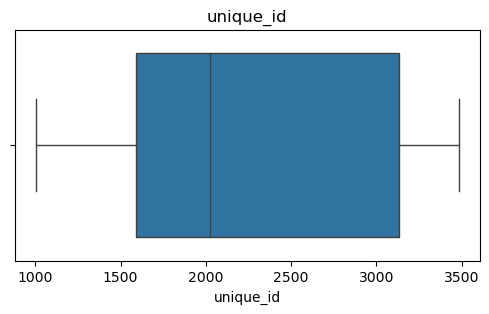

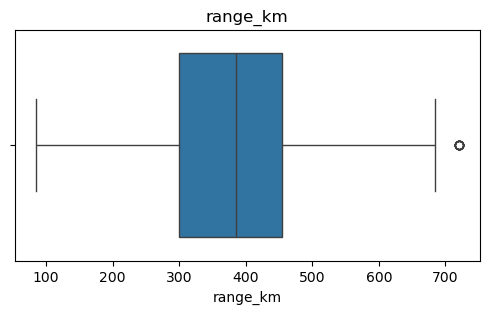

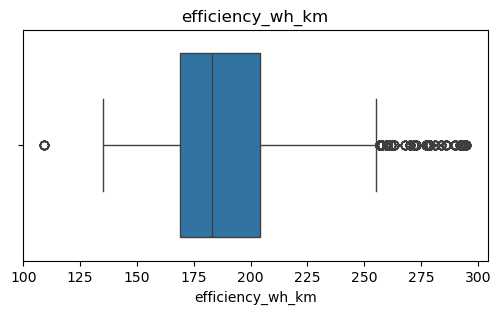

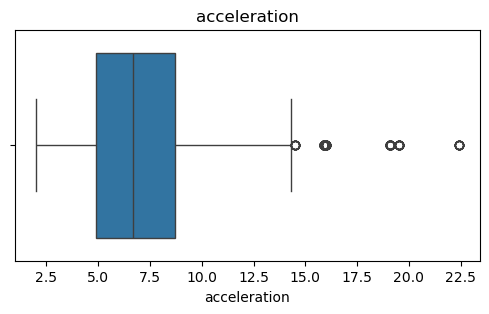

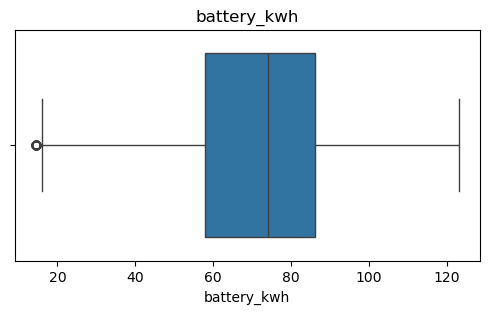

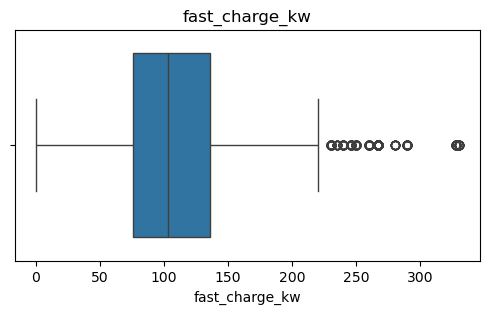

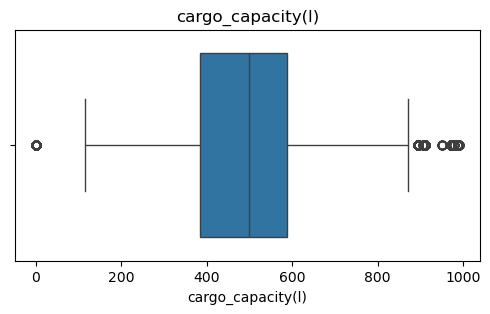

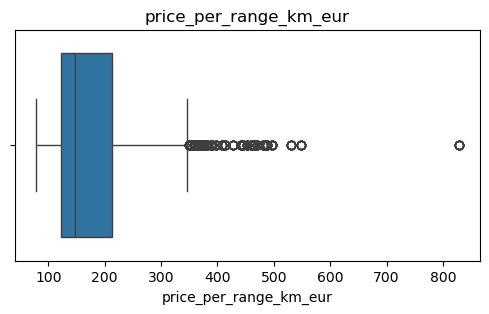

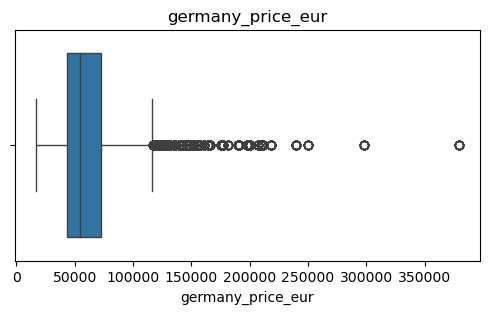

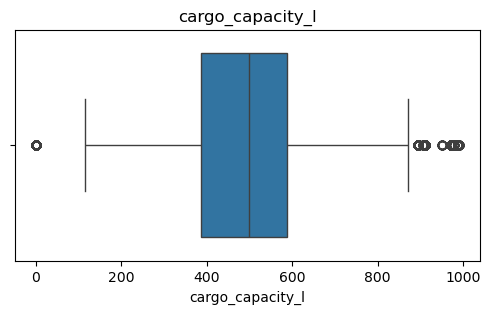

In [207]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in num_cols:
    
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

In [208]:
def Hand_outliers(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data[column] = data[column].clip(lower, upper)
    
    return data

In [209]:
for i in num_cols:
    
    df1 = Hand_outliers(df, i)

df1

,brand,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur,segment,range_group,cargo_capacity_l
0,BMW,3290,610.0,178.0,4.9,108.7,226.0,578.0,114.0,70900.0,D - Large,premium,578.0
1,MG,1708,360.0,171.0,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium,mid,363.0
2,Tesla,3403,445.0,135.0,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large,long,682.0
3,BMW,1472,360.0,197.0,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive,mid,500.0
4,Mercedes,3139,585.0,145.0,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large,premium,506.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,Porsche,1931,425.0,197.0,3.3,83.7,200.0,489.0,349.5,116265.0,F - Luxury,long,489.0
12326,Opel,1345,185.0,250.0,12.1,46.3,74.0,NaN,306.0,56700.0,N - Passenger Van,short,603.0
12327,Ford,3164,235.0,256.5,9.0,64.0,105.0,819.0,295.0,67771.0,N - Passenger Van,short,819.0
12328,Citroen,1340,185.0,250.0,12.1,46.3,74.0,140.0,275.0,50880.0,N - Passenger Van,short,140.0


In [210]:
outlier_check_after = []

for col in num_cols:
    result = detect_outliers(df, col)
    outlier_check_after.append(result)

pd.DataFrame(outlier_check_after)

,column,lower_bound,upper_bound,outlier_count
0,unique_id,-722.5,5441.5,0
1,range_km,67.5,687.5,0
2,efficiency_wh_km,116.5,256.5,0
3,acceleration,-0.8,14.4,0
4,battery_kwh,16.0,128.0,0
5,fast_charge_kw,-14.0,226.0,0
6,cargo_capacity(l),80.5,892.5,0
7,price_per_range_km_eur,-14.5,349.5,0
8,germany_price_eur,-175.0,116265.0,0
9,cargo_capacity_l,88.0,888.0,0


# Dropping_duplicates

In [211]:
df = df.drop_duplicates()

In [212]:
df

,brand,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur,segment,range_group,cargo_capacity_l
0,BMW,3290,610.0,178.0,4.9,108.7,226.0,578.0,114.0,70900.0,D - Large,premium,578.0
1,MG,1708,360.0,171.0,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium,mid,363.0
2,Tesla,3403,445.0,135.0,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large,long,682.0
3,BMW,1472,360.0,197.0,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive,mid,500.0
4,Mercedes,3139,585.0,145.0,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large,premium,506.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1228,Porsche,1931,425.0,197.0,3.3,83.7,200.0,489.0,349.5,116265.0,F - Luxury,long,489.0
1229,Opel,1345,185.0,250.0,12.1,46.3,74.0,NaN,306.0,56700.0,N - Passenger Van,short,603.0
1230,Ford,3164,235.0,256.5,9.0,64.0,105.0,819.0,295.0,67771.0,N - Passenger Van,short,819.0
1231,Citroen,1340,185.0,250.0,12.1,46.3,74.0,140.0,275.0,50880.0,N - Passenger Van,short,140.0


In [213]:
df.to_csv("EV_Market_Analysis_Final.csv",index = False)

# Feature Engineering 

| Feature                  | Meaning                       | Why it matters                 |
| ------------------------ | ----------------------------- | ------------------------------ |
| `range_per_kwh`          | km per kWh                    | Engineering efficiency         |
| `price_per_km`           | price divided by range        | Consumer value metric          |
| `charge_speed_per_kwh`   | charging capability           | Charging convenience           |
| `price_per_range_km_eur` | price relative to range       | Market value comparison        |
| `range_group`            | premium/long/mid segmentation | useful for clustering vehicles |


**price_per_km**  
Cost of the vehicle relative to its driving range.

Formula:

`price_per_range_km = germany_price_eur / range_km`

---

**range_per_kwh**  
Driving distance achieved per unit of battery energy, representing energy utilization efficiency.

Formula:

`range_per_kwh = range_km / battery_kwh`

---

**charge_speed_per_kwh**  
Charging capability relative to battery capacity, indicating how quickly the battery can recharge per unit of battery size.

Formula:

`charge_speed_per_kwh = fast_charge_kw / battery_kwh`

In [214]:
df["Range_per_kWh"] = df["range_km"] / df["battery_kwh"]

# Engineering Efficiency Score

# Meaning:
# How many km per kWh?
# Industry interpretation:
# Higher = better battery efficiency
# Tesla usually high here

In [215]:
df["Price_per_km"] = df["germany_price_eur"] / df["range_km"]

In [216]:
df["Charge_Speed_per_kWh"] = df["fast_charge_kw"] / df["battery_kwh"]

In [217]:
df.head()

,brand,unique_id,range_km,efficiency_wh_km,acceleration,battery_kwh,fast_charge_kw,cargo_capacity(l),price_per_range_km_eur,germany_price_eur,segment,range_group,cargo_capacity_l,Range_per_kWh,Price_per_km,Charge_Speed_per_kWh
0,BMW,3290,610.0,178.0,4.9,108.7,226.0,578.0,114.0,70900.0,D - Large,premium,578.0,5.611776,116.229508,2.079117
1,MG,1708,360.0,171.0,7.9,61.7,107.0,363.0,103.0,39990.0,C - Medium,mid,363.0,5.834684,111.083333,1.734198
2,Tesla,3403,445.0,135.0,6.2,60.0,110.0,682.0,89.0,37970.0,D - Large,long,682.0,7.416667,85.325843,1.833333
3,BMW,1472,360.0,197.0,6.1,71.0,92.0,500.0,225.0,77300.0,E - Executive,mid,500.0,5.070423,214.722222,1.295775
4,Mercedes,3139,585.0,145.0,6.7,85.0,208.0,506.0,92.0,55728.0,D - Large,premium,506.0,6.882353,95.261538,2.447059


# Data Visualization

# Univariate Analysis

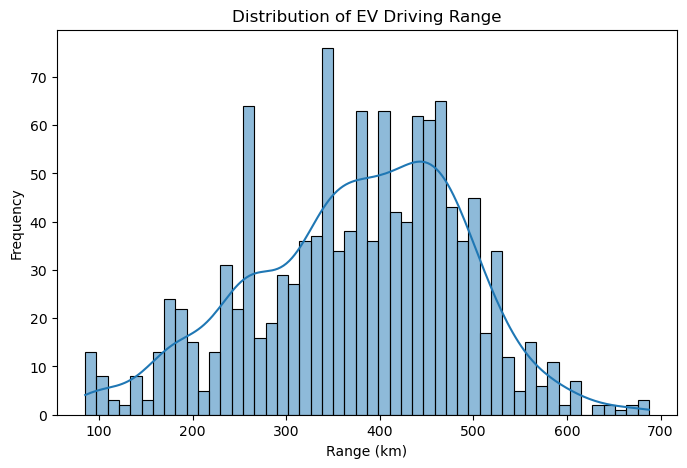

In [147]:
# Range Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["range_km"], bins=50, kde=True)

plt.title("Distribution of EV Driving Range")
plt.xlabel("Range (km)")
plt.ylabel("Frequency")
plt.show()

### Insight : The EV market currently clusters around mid-range vehicles, suggesting manufacturers are optimizing for balanced affordability and usable range rather than extreme long-range vehicles.

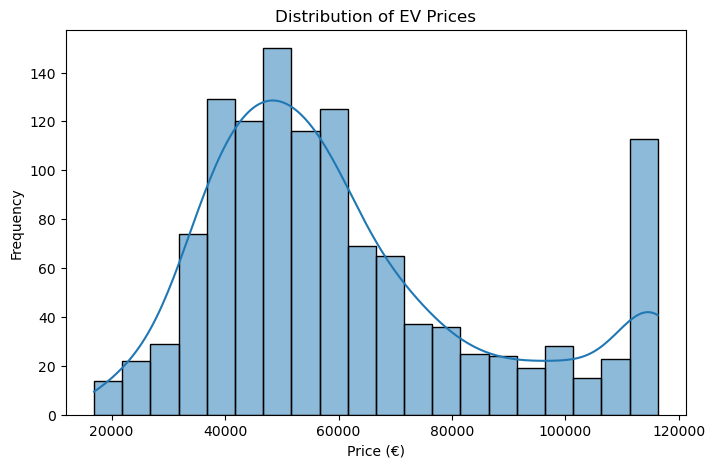

In [148]:
# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["germany_price_eur"], bins=20, kde=True)

plt.title("Distribution of EV Prices")
plt.xlabel("Price (€)")
plt.ylabel("Frequency")
plt.show()

### Insight : The EV market shows strong price stratification, with most vehicles concentrated in the €40k–€70k range, indicating this is the primary competitive zone.

<Axes: xlabel='battery_kwh', ylabel='Count'>

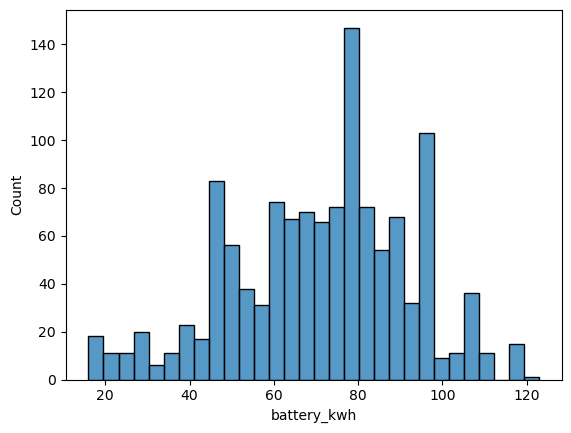

In [149]:
# Battery Capacity
sns.histplot(df["battery_kwh"], bins=30)

### Insight : Battery capacity around 70 kWh appears to be the industry standard for balancing cost, weight, and range.

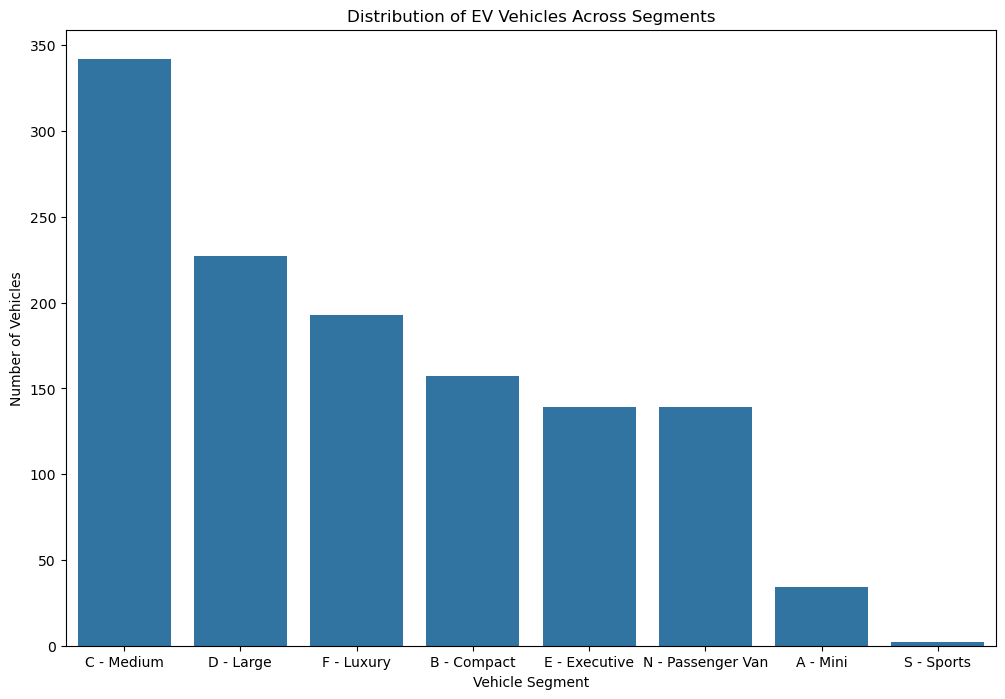

In [150]:
# Segment Distribution
plt.figure(figsize=(12,8))
sns.countplot(data=df, x="segment", order=df["segment"].value_counts().index)

plt.title("Distribution of EV Vehicles Across Segments")
plt.xlabel("Vehicle Segment")
plt.ylabel("Number of Vehicles")
plt.show()

### Insight : Manufacturers are focusing heavily on mid-size and large segments, which represent the largest consumer demand for EVs.

# Bivariate Analysis

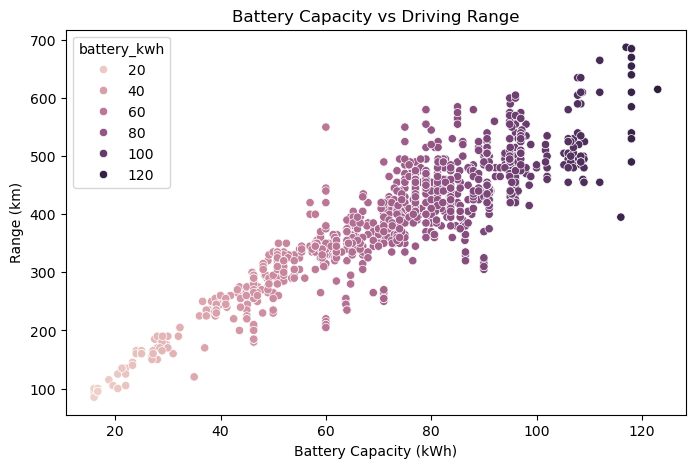

In [151]:
# Battery capacity vs Range

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="battery_kwh", y="range_km",hue = "battery_kwh")

plt.title("Battery Capacity vs Driving Range")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.show()

### Insight :Vehicles with larger battery capacity generally deliver higher driving range, confirming battery size as the primary determinant of EV range.

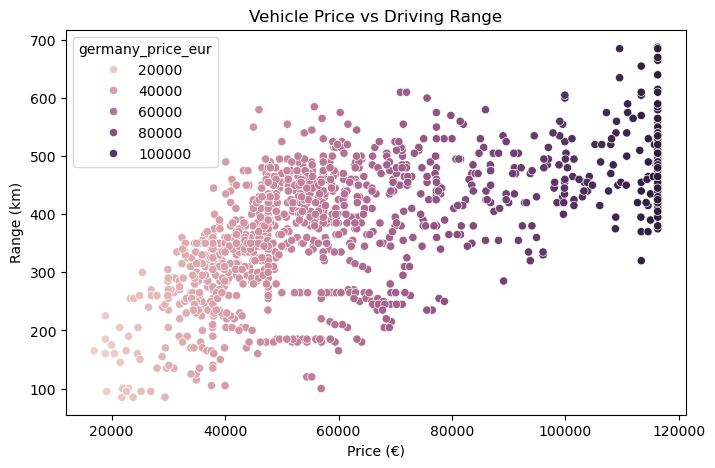

In [152]:
# Price vs Range

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="germany_price_eur", y="range_km",hue = "germany_price_eur" )

plt.title("Vehicle Price vs Driving Range")
plt.xlabel("Price (€)")
plt.ylabel("Range (km)")
plt.show()

### Insight : Some manufacturers achieve better range efficiency at lower prices, suggesting technology differences between brands.
- This is key for consumer value analysis.

<Axes: xlabel='segment', ylabel='germany_price_eur'>

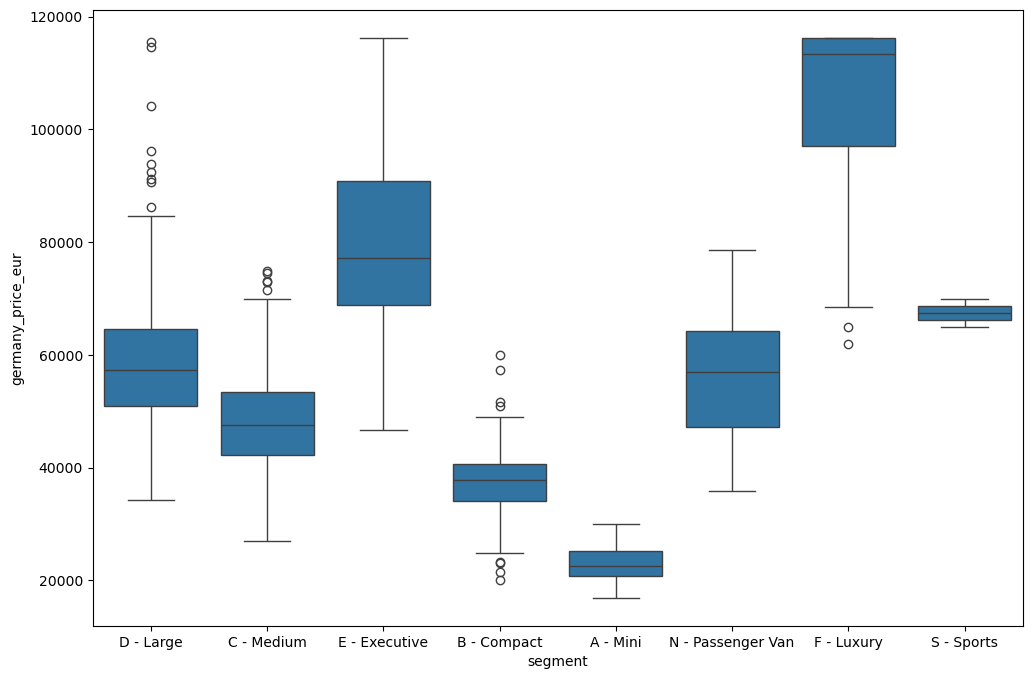

In [153]:
# Segment vs Price
plt.figure(figsize = (12,8))
sns.boxplot(x="segment", y="germany_price_eur", data=df)

### Observation
- Luxury segments show significantly higher price distribution.
### Insight
- Vehicle segments strongly influence pricing strategy, with higher segments commanding premium pricing independent of technical specifications.

# Multi-Variate Analysis

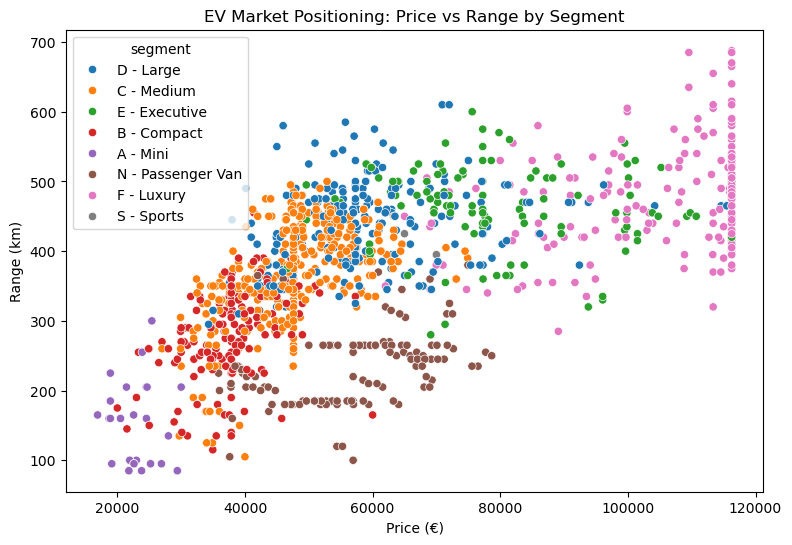

In [218]:
# Price vs Range by Segment

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="germany_price_eur",
    y="range_km",
    hue="segment"
)

plt.title("EV Market Positioning: Price vs Range by Segment")
plt.xlabel("Price (€)")
plt.ylabel("Range (km)")
plt.show()

# Insight
    - Segments cluster differently:
    - C segment → moderate price, moderate range
    - D segment → higher range
    - Luxury segments → highest price but not always proportionally higher range
Meaning:
Some luxury vehicles charge a premium for branding rather than performance gains.

In [219]:
df.columns

Index(['brand', 'unique_id', 'range_km', 'efficiency_wh_km', 'acceleration',
       'battery_kwh', 'fast_charge_kw', 'cargo_capacity(l)',
       'price_per_range_km_eur', 'germany_price_eur', 'segment', 'range_group',
       'cargo_capacity_l', 'Range_per_kWh', 'Price_per_km',
       'Charge_Speed_per_kWh'],
      dtype='object')

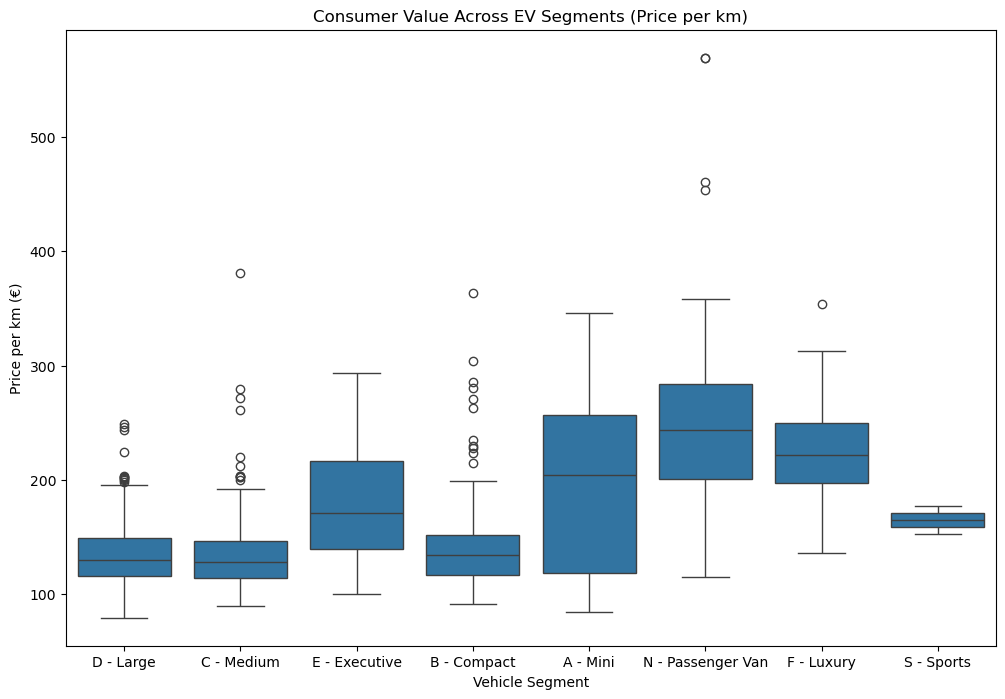

In [220]:
# Consumer Value by Segment

plt.figure(figsize=(12,8))

sns.boxplot(
    data=df,
    x="segment",
    y="Price_per_km"
)

plt.title("Consumer Value Across EV Segments (Price per km)")
plt.xlabel("Vehicle Segment")
plt.ylabel("Price per km (€)")
plt.show()

### Insight : Segments with lowest price_per_km deliver the best consumer value.


<Axes: xlabel='segment', ylabel='Range_per_kWh'>

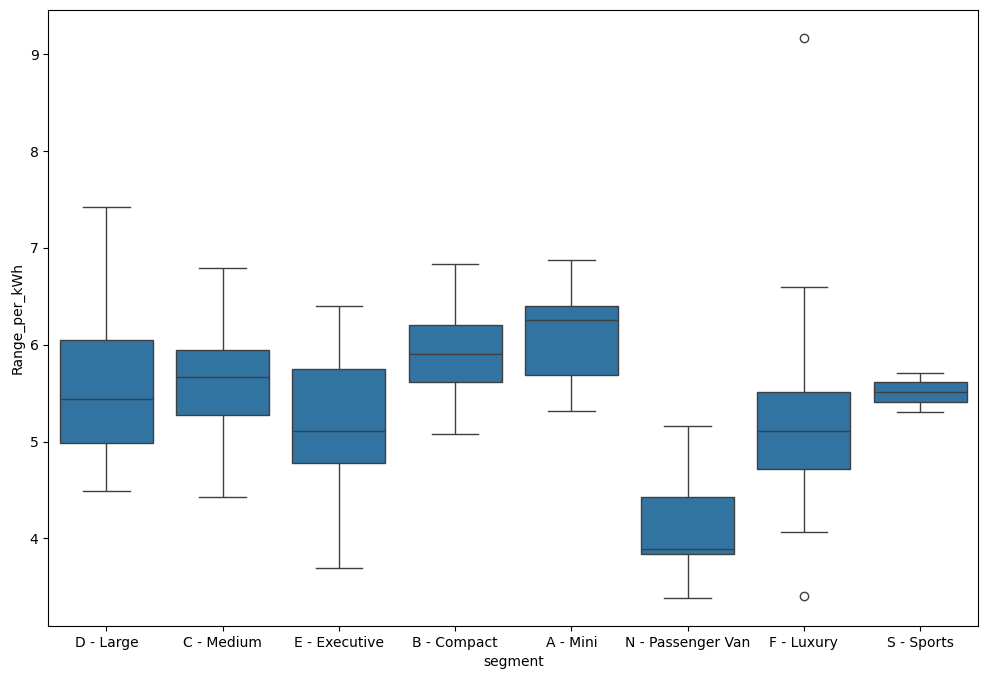

In [227]:
# Efficiency Analysis

plt.figure(figsize=(12,8))
sns.boxplot(x="segment", y='Range_per_kWh', data=df)


### Insight : Some segments achieve better energy efficiency, meaning they travel further using the same battery capacity.
- Efficiency differences reflect vehicle design and aerodynamics.


<Axes: xlabel='segment', ylabel='Charge_Speed_per_kWh'>

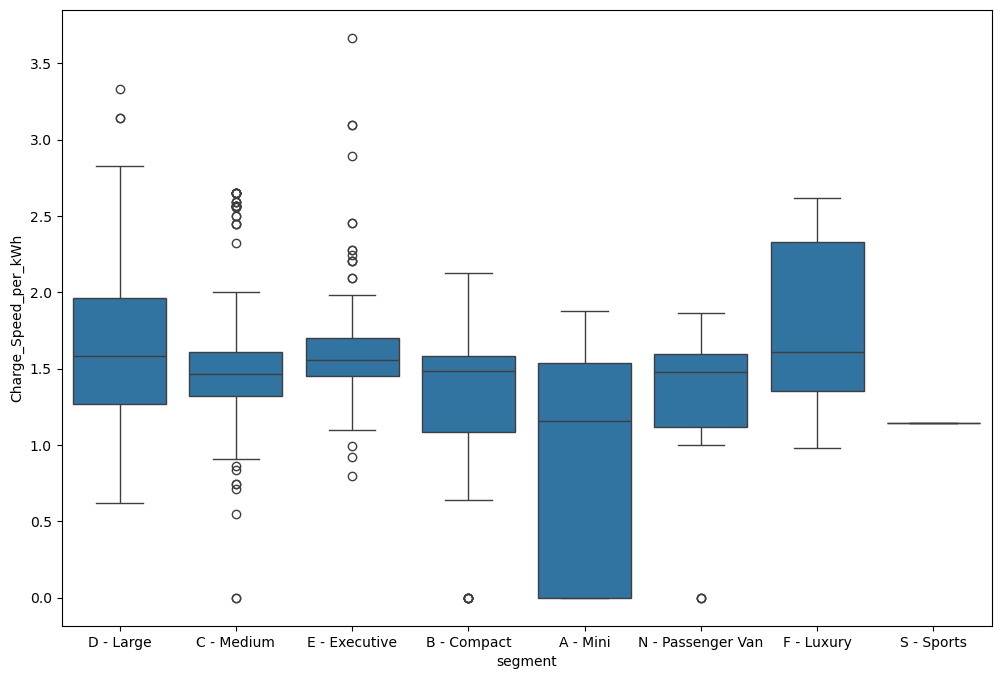

In [228]:
# Charging Capability
plt.figure(figsize=(12,8))
sns.boxplot(x="segment", y="Charge_Speed_per_kWh", data=df)

# Insight : Higher segments generally support faster charging, improving long-distance usability.

# Correlation Analysis

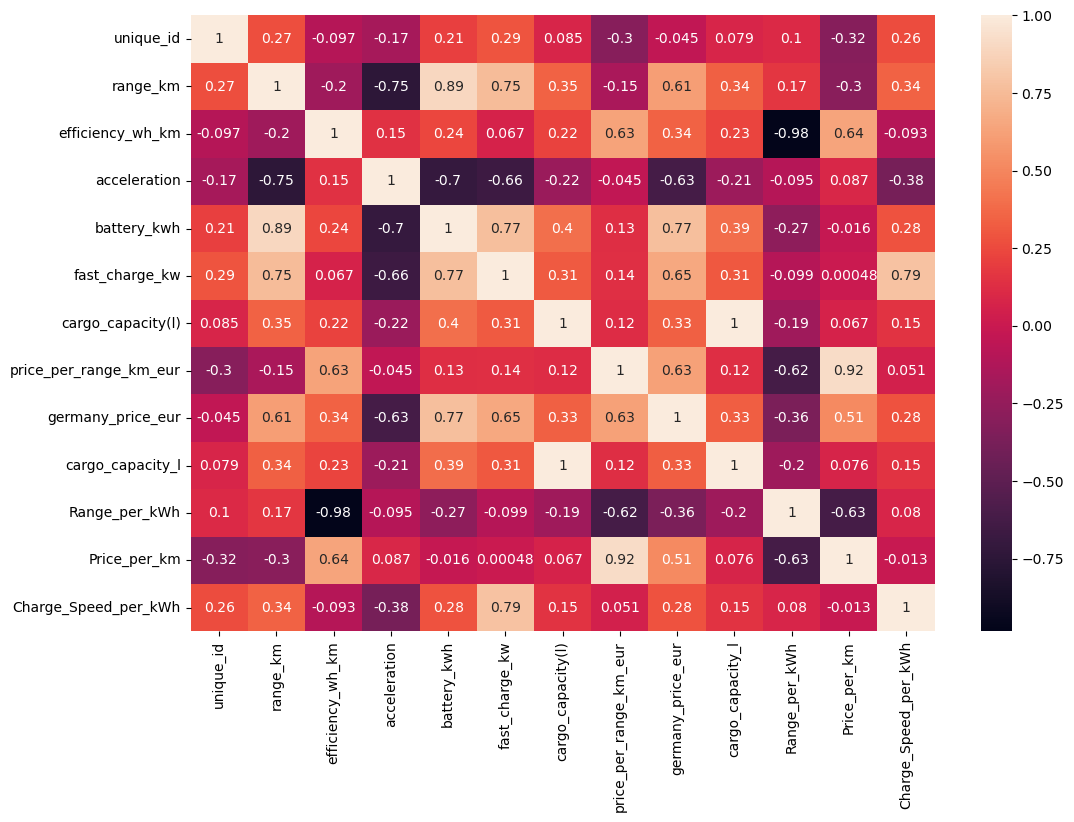

In [229]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

# Insight : Strong correlations likely between
- battery_kwh ↔ range_km
- price ↔ battery_kwh
- price ↔ range
### Meaning:
- Battery and range are major drivers of EV price.

# Problem Statement : Analysis on EV car market by quantifying across vehicle segments that deliver the best consumer value. 


### Here Analysis is based on Segment Comparison

In [230]:
df.pivot_table(
    values=["Price_per_km","Range_per_kWh","Charge_Speed_per_kWh"],
    index="segment",
    aggfunc="mean",
    margins= True,
    margins_name="TOTAL"

)


,Charge_Speed_per_kWh,Price_per_km,Range_per_kWh
segment,,,
A - Mini,0.990914,191.851312,6.066543
B - Compact,1.341652,142.369990,5.894204
C - Medium,1.496979,133.613441,5.623138
D - Large,1.646164,136.408248,5.576712
E - Executive,1.634571,177.911716,5.192547
F - Luxury,1.762436,224.559486,5.149958
N - Passenger Van,1.340596,247.882184,4.045291
S - Sports,1.142473,165.053760,5.510753
TOTAL,1.529570,169.011308,5.360667


# Strategic Insights

### EV Market Value Map
    This plot shows:
    X-axis: Price
    Y-axis: Range
    Bubble size: Battery capacity
    Color: Segment
    So in one chart you understand:
    market positioning
    vehicle capability
    segment clustering

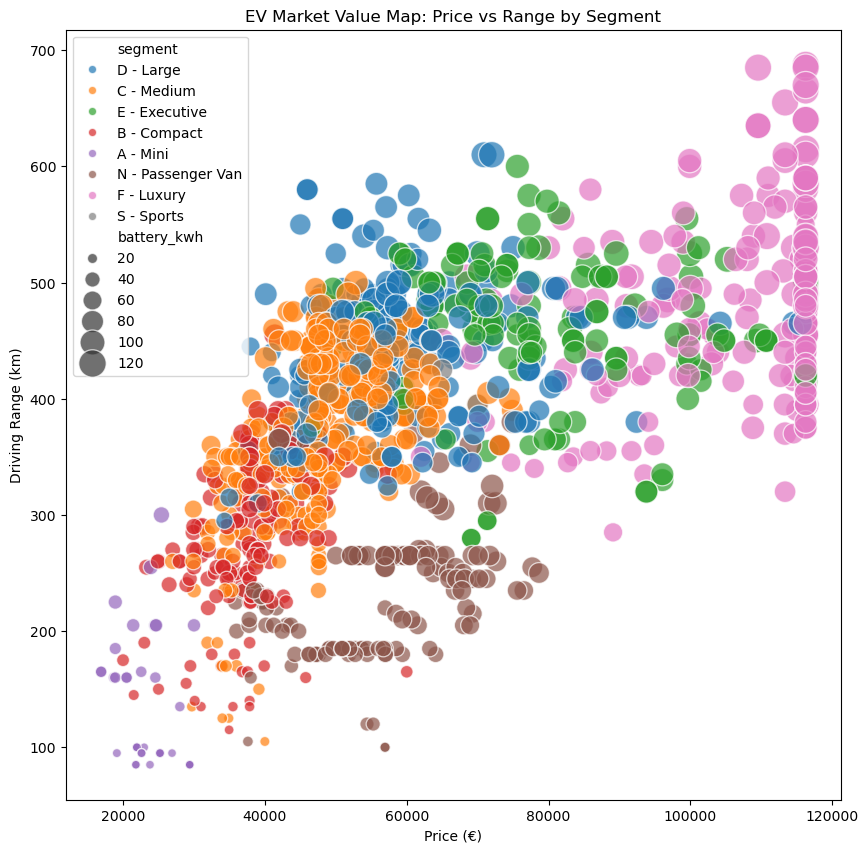

In [231]:
plt.figure(figsize=(10,10))

sns.scatterplot(
    data=df,
    x="germany_price_eur",
    y="range_km",
    hue="segment",
    size="battery_kwh",
    sizes=(40,400),
    alpha=0.7
)

plt.title("EV Market Value Map: Price vs Range by Segment")
plt.xlabel("Price (€)")
plt.ylabel("Driving Range (km)")

plt.show()

# Insight :
- Entry-level EVs target price-sensitive consumers but sacrifice driving range.
- The majority of EV models cluster between €40k–€70k with ranges around 350–450 km, indicating this range-price combination represents the current market equilibrium.
- Premium EVs deliver extended range but at significantly higher prices, targeting high-income consumers prioritizing performance.

# Consumer Value Frontier


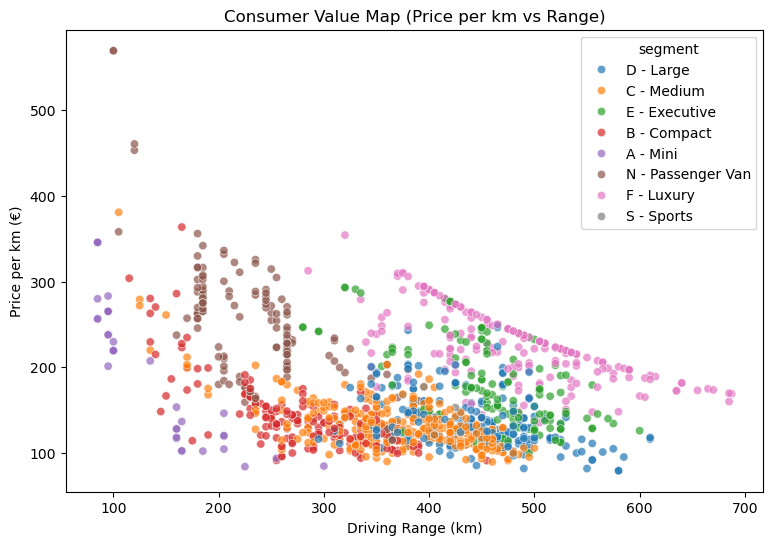

In [234]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="range_km",
    y="Price_per_km",
    hue="segment",
    alpha=0.7
)

plt.title("Consumer Value Map (Price per km vs Range)")
plt.xlabel("Driving Range (km)")
plt.ylabel("Price per km (€)")

plt.show()

### Insight : Mid-size EV segments deliver the strongest consumer value by combining competitive driving range with relatively lower price per kilometer. In contrast, premium segments command significantly higher prices without proportional increases in range efficiency.

# Final Conclusion
**Based on the analysis:**
- Market structure : 
The EV market is dominated by mid-size and large vehicle segments, which represent the majority of available models.
- Consumer value : 
Segments such as C – Medium and D – Large tend to offer the best price-to-range value, making them the most cost-efficient choices for consumers.
- Engineering efficiency : 
Vehicles across segments show relatively consistent energy efficiency, with most EVs achieving 5–6 km per kWh, indicating mature battery technology across the market.
- Premium segments :
Luxury EV segments command significantly higher prices, but the increase in range and efficiency is not always proportional, suggesting pricing reflects brand positioning rather than purely technical performance.
- Charging capability :
Higher segments tend to provide faster charging infrastructure compatibility, improving usability for long-distance travel.